# Explainable AI Lab: Local Explanations with **LIME**
### Dataset: Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository (ID = 17)



---

## Learning Objectives

By the end of this notebook you should be able to:

1. Load a benchmark dataset directly from the **UCI ML Repository** and prepare it for modelling.
2. Train and evaluate a **black-box classifier** (Random Forest) against an interpretable baseline (Logistic Regression).
3. Explain the **mathematical formulation** of LIME (Local Interpretable Model-agnostic Explanations).
4. Generate and *correctly read* **local explanations** for individual predictions.
5. Diagnose **misclassifications** using explanations rather than guesswork.
6. Assess the **local fidelity** and **stability** of an explanation — the two properties most students forget to check.
7. Articulate the **limitations** of LIME and how it compares with SHAP.

## Prerequisites
Python, `numpy`/`pandas`, basic supervised learning, elementary linear algebra and probability.

## 1. Motivation — The Black-Box Problem

A Random Forest with 500 trees may achieve 96% accuracy on cancer diagnosis, but a clinician cannot act on
"the ensemble said malignant". Regulations such as the EU GDPR *right to explanation* and, in India,
the DPDP Act's transparency obligations, make this a practical engineering requirement, not a philosophical one.

Interpretability methods split along two axes:

| Axis | Option A | Option B |
|---|---|---|
| **Scope** | **Global** — how the model behaves overall (e.g. permutation importance) | **Local** — why *this one* prediction was made (LIME, SHAP) |
| **Coupling** | **Model-specific** — needs internals (tree paths, gradients) | **Model-agnostic** — only needs `predict_proba` |

> **LIME is local + model-agnostic.** It answers: *"Which features pushed the model towards this label, for this particular patient?"*

A high global importance for `worst area` does **not** mean `worst area` drove *this* patient's prediction.
That gap is exactly why local methods exist.

In [1]:
# Run once if the packages are missing. Restart the kernel afterwards.
# !pip install -q lime ucimlrepo scikit-learn pandas matplotlib seaborn

In [2]:
import warnings, sys
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import lime
import lime.lime_tabular

SEED = 42
np.random.seed(SEED)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)
print("LIME        :", lime.__version__ if hasattr(lime, "__version__") else "installed")

Python      : 3.13.4
NumPy       : 2.3.3
pandas      : 2.3.1
scikit-learn: 1.7.2
LIME        : installed


## 2. The Dataset — Breast Cancer Wisconsin (Diagnostic)

| Property | Value |
|---|---|
| UCI ID | **17** |
| Instances | 569 |
| Features | 30 numeric, real-valued |
| Target | Diagnosis: **M** = malignant, **B** = benign |
| Missing values | None |
| Task | Binary classification |

Features are computed from a digitised image of a **fine needle aspirate (FNA)** of a breast mass.
Ten base measurements are taken for each cell nucleus — *radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension* — and for each of these the
**mean**, **standard error** and **worst** (mean of the three largest values) are recorded, giving 10 × 3 = 30 features.

**Encoding convention used throughout this notebook:** `1 = Malignant` (the positive / clinically important class),
`0 = Benign`. Note that scikit-learn's bundled copy uses the *opposite* convention, so we invert it for consistency.

In [3]:
def load_uci_breast_cancer(verbose=True):
    # Primary path : fetch live from the UCI ML Repository via the official `ucimlrepo` API.
    # Fallback path: identical copy bundled with scikit-learn (for offline / firewalled labs).
    # Returns: X (DataFrame), y (1 = Malignant), feature_names, class_names, source
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=17)                 # 17 = Breast Cancer Wisconsin (Diagnostic)
        X = ds.data.features.copy()
        y_raw = ds.data.targets.iloc[:, 0]
        y = (y_raw.astype(str).str.upper().str[0] == "M").astype(int).to_numpy()
        source = "UCI ML Repository (live fetch, id=17)"
        if verbose:
            print(ds.metadata["name"], "|", ds.metadata["abstract"][:90], "...")
    except Exception as e:
        from sklearn.datasets import load_breast_cancer
        if verbose:
            print(f"[!] Live UCI fetch unavailable ({type(e).__name__}). "
                  f"Falling back to the identical scikit-learn copy.")
        d = load_breast_cancer(as_frame=True)
        X = d.data.copy()
        y = 1 - d.target.to_numpy()               # invert: sklearn uses 0=malignant
        source = "scikit-learn bundled copy of UCI dataset 17"

    X.columns = [c.strip() for c in X.columns]
    return X, y, list(X.columns), ["Benign", "Malignant"], source


X, y, feature_names, class_names, SOURCE = load_uci_breast_cancer()

print("\nSource     :", SOURCE)
print("Shape      :", X.shape)
print("Classes    :", dict(zip(class_names, np.bincount(y))))
print("Malignant %: {:.1f}%".format(100 * y.mean()))
X.head()

Breast Cancer Wisconsin (Diagnostic) | Diagnostic Wisconsin Breast Cancer Database. ...

Source     : UCI ML Repository (live fetch, id=17)
Shape      : (569, 30)
Classes    : {'Benign': np.int64(357), 'Malignant': np.int64(212)}
Malignant %: 37.3%


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Quick sanity checks — always do these before modelling
print("Missing values :", int(X.isna().sum().sum()))
print("Duplicate rows :", int(X.duplicated().sum()))
print("Dtypes         :", set(map(str, X.dtypes)))

display(X.iloc[:, :6].describe().T.round(3))

Missing values : 0
Duplicate rows : 0
Dtypes         : {'float64'}


,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture1,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter1,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area1,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness1,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness1,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345


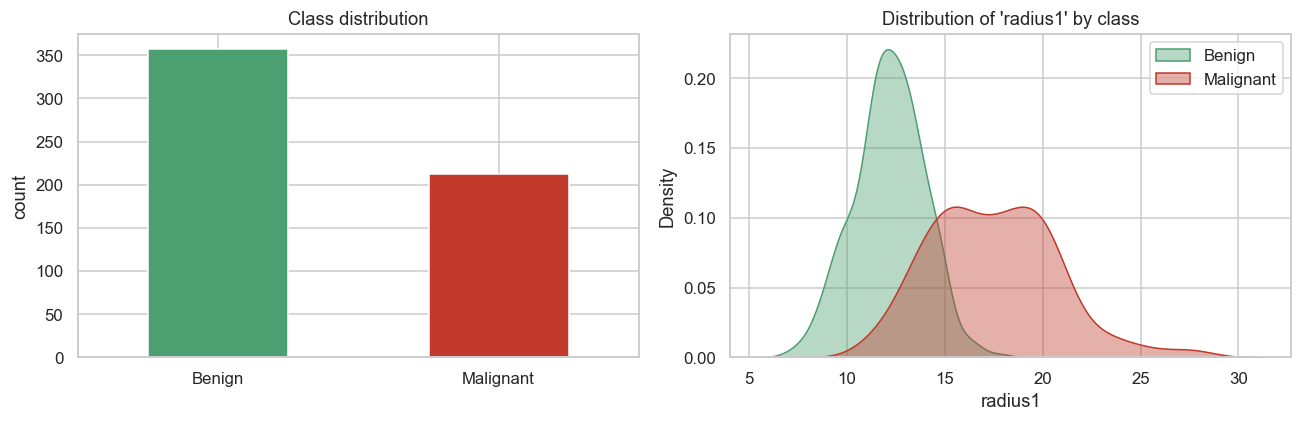

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) class balance
pd.Series(y).map({0: "Benign", 1: "Malignant"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C9F70", "#C0392B"], rot=0)
axes[0].set_title("Class distribution"); axes[0].set_ylabel("count")

# (b) one discriminative feature
col = feature_names[0]   # 'mean radius' / 'radius1'
for lab, name, c in [(0, "Benign", "#4C9F70"), (1, "Malignant", "#C0392B")]:
    sns.kdeplot(X.loc[y == lab, col], ax=axes[1], fill=True, alpha=.4, label=name, color=c)
axes[1].set_title(f"Distribution of '{col}' by class"); axes[1].legend()
plt.tight_layout(); plt.show()

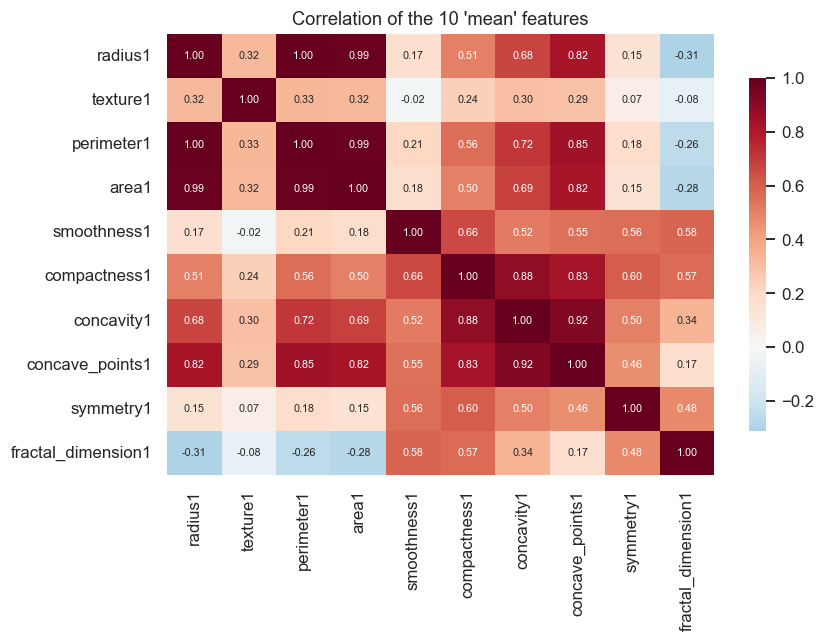

In [6]:
# Correlation among the first 10 (the "mean") features — note the strong block structure.
plt.figure(figsize=(8, 6))
sns.heatmap(X.iloc[:, :10].corr(), cmap="RdBu_r", center=0, annot=True,
            fmt=".2f", annot_kws={"size": 7}, cbar_kws={"shrink": .8})
plt.title("Correlation of the 10 'mean' features")
plt.tight_layout(); plt.show()

> **Observation to carry forward.** `radius`, `perimeter` and `area` are almost perfectly correlated
> (r ≈ 0.99) — they are geometrically redundant. **Correlated features are LIME's known weak spot**:
> credit for a prediction gets split arbitrarily among them, and perturbation generates unrealistic
> synthetic points (a cell with a large radius but tiny area). Keep this in mind in Section 9.

## 3. Train / Test Split and a Critical Design Decision

**Where should the scaler live?**

LIME perturbs data **in the feature space you hand to the explainer** and reports weights in
those same units. If you scale first and pass standardised data, every explanation reads
`worst area <= -0.42` — meaningless to a clinician.

✅ **Correct pattern:** keep the scaler *inside* an sklearn `Pipeline`, give LIME the **raw** training data,
and pass `pipeline.predict_proba` as the prediction function. The pipeline scales internally; the
explanation stays in original units (mm, µm², …).

Tree ensembles do not need scaling at all, so our Random Forest consumes raw features directly.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]} samples  ({100*y_train.mean():.1f}% malignant)")
print(f"Test : {X_test.shape[0]} samples  ({100*y_test.mean():.1f}% malignant)")

# LIME works on NumPy arrays
X_train_np = X_train.to_numpy()
X_test_np  = X_test.to_numpy()

Train: 426 samples  (37.3% malignant)
Test : 143 samples  (37.1% malignant)


## 4. Models: an Interpretable Baseline vs. a Black Box

We deliberately train two models:

* **Logistic Regression** — *intrinsically interpretable*. Its coefficients ARE a global explanation.
  This is our reference point; if it matched the Random Forest's accuracy we would not need LIME at all.
* **Random Forest (400 trees)** — *black box*. No single coefficient exists; the decision is spread
  over thousands of split conditions. This is the model we will explain.

In [8]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=SEED))
])

rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    n_jobs=-1, random_state=SEED)

logreg.fit(X_train_np, y_train)
rf.fit(X_train_np, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, model in [("Logistic Regression", logreg), ("Random Forest", rf)]:
    s = cross_val_score(model, X_train_np, y_train, cv=cv, scoring="roc_auc")
    print(f"{name:22s}  5-fold CV ROC-AUC = {s.mean():.4f} (+/- {s.std():.4f})")

Logistic Regression     5-fold CV ROC-AUC = 0.9914 (+/- 0.0090)


Random Forest           5-fold CV ROC-AUC = 0.9874 (+/- 0.0089)


In [9]:
def evaluate(model, name):
    y_pred  = model.predict(X_test_np)
    y_proba = model.predict_proba(X_test_np)[:, 1]
    print(f"\n{'='*58}\n{name}\n{'='*58}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}\n")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=3))
    return y_pred, y_proba

_,        proba_lr = evaluate(logreg, "Logistic Regression (interpretable baseline)")
y_pred_rf, proba_rf = evaluate(rf,    "Random Forest (black box -> to be explained)")


Logistic Regression (interpretable baseline)
Accuracy : 0.9650
ROC-AUC  : 0.9962

              precision    recall  f1-score   support

      Benign      0.957     0.989     0.973        90
   Malignant      0.980     0.925     0.951        53

    accuracy                          0.965       143
   macro avg      0.968     0.957     0.962       143
weighted avg      0.966     0.965     0.965       143


Random Forest (black box -> to be explained)
Accuracy : 0.9650
ROC-AUC  : 0.9960

              precision    recall  f1-score   support

      Benign      0.947     1.000     0.973        90
   Malignant      1.000     0.906     0.950        53

    accuracy                          0.965       143
   macro avg      0.974     0.953     0.962       143
weighted avg      0.967     0.965     0.965       143



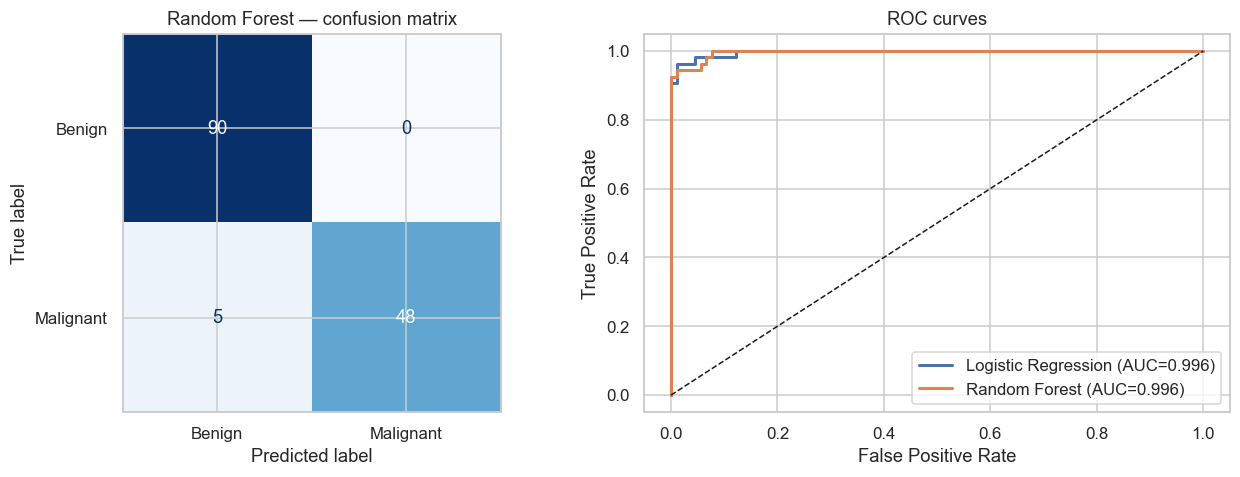

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=class_names).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Random Forest — confusion matrix")

for nm, pr in [("Logistic Regression", proba_lr), ("Random Forest", proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, pr)
    axes[1].plot(fpr, tpr, lw=2, label=f"{nm} (AUC={roc_auc_score(y_test, pr):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curves"); axes[1].legend(loc="lower right")

plt.tight_layout(); plt.show()

> In a screening context a **false negative** (malignant predicted benign) is far costlier than a false
> positive. Note the recall on the *Malignant* row above — that, not accuracy, is the number that matters.
> In Section 7 we will use LIME to interrogate exactly these errors.

## 5. How LIME Works — The Theory

### 5.1 Core idea
A complex decision boundary $f$ can be wildly non-linear **globally**, yet be well approximated by a
**straight line in a small neighbourhood** of a single point $x$. LIME fits that local line.

### 5.2 The optimisation problem

$$\xi(x) \;=\; \underset{g \in G}{\arg\min}\; \mathcal{L}\big(f,\, g,\, \pi_x\big) \;+\; \Omega(g)$$

| Symbol | Meaning |
|---|---|
| $f$ | the black-box model (Random Forest); we only query `f.predict_proba` |
| $G$ | class of interpretable models — here **sparse linear regression** |
| $g \in G$ | the local surrogate we fit and show to the user |
| $\pi_x(z)$ | proximity kernel weighting a perturbed sample $z$ by closeness to $x$ |
| $\mathcal{L}$ | weighted squared loss between $f(z)$ and $g(z')$ — the **infidelity** |
| $\Omega(g)$ | complexity penalty — here "use at most $K$ features" (via LASSO path) |

The **exponential kernel** with width $\sigma$:

$$\pi_x(z) \;=\; \exp\!\left(-\,\frac{D(x, z)^2}{\sigma^{2}}\right)$$

and the loss actually minimised:

$$\mathcal{L}(f, g, \pi_x) \;=\; \sum_{z, z' \in \mathcal{Z}} \pi_x(z)\,\big(f(z) - g(z')\big)^{2}$$

### 5.3 Algorithm (tabular data)

1. **Perturb** — draw $N$ (default 5000) synthetic samples around $x$ by sampling each feature from
   $\mathcal{N}(\mu_j, \sigma_j)$ estimated on the training set, then re-centre on $x$.
2. **Label** — query the black box: $f(z)$ for every synthetic sample. *This is the only access LIME needs.*
3. **Weight** — compute $\pi_x(z)$; samples near $x$ dominate the fit.
4. **Select** — pick $K$ features (forward selection / LASSO path).
5. **Fit** — weighted ridge regression of $f(z)$ on the $K$ features.
6. **Report** — the coefficients of $g$ are the explanation.

### 5.4 Discretisation — the part students misread
By default `discretize_continuous=True` bins each continuous feature into quartiles. The surrogate then
operates on **binary indicators** ("is this feature in bin 3?"), which is why explanations read as
`worst perimeter > 125.40` rather than as a slope. The weight answers:

> *"Given that this feature falls in **this bin**, how much probability mass is added to / removed from the predicted class?"*

Set `discretize_continuous=False` if you want raw continuous coefficients instead.

In [11]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data      = X_train_np,     # RAW units -> readable explanations
    feature_names      = feature_names,
    class_names        = class_names,
    mode               = "classification",
    discretize_continuous = True,        # quartile bins -> "feature > 125.40"
    discretizer        = "quartile",
    random_state       = SEED,
    verbose            = False
)
print("Explainer ready. Statistics estimated from", X_train_np.shape[0], "training rows.")

Explainer ready. Statistics estimated from 426 training rows.


## 6. Explaining a Single Prediction

We pick a confidently-predicted **malignant** test case and ask the Random Forest to justify itself.

In [12]:
# choose a high-confidence malignant prediction
mal_idx  = np.where((y_test == 1) & (proba_rf > 0.95))[0]
idx      = int(mal_idx[0])
x        = X_test_np[idx]

print(f"Test instance #{idx}")
print(f"  True label      : {class_names[y_test[idx]]}")
print(f"  RF prediction   : {class_names[y_pred_rf[idx]]}")
print(f"  P(Malignant)    : {proba_rf[idx]:.4f}")

Test instance #0
  True label      : Malignant
  RF prediction   : Malignant
  P(Malignant)    : 0.9509


In [13]:
exp = explainer.explain_instance(
    data_row      = x,
    predict_fn    = rf.predict_proba,
    num_features  = 10,      # K in Omega(g)
    num_samples   = 5000,    # N perturbations
    labels        = (1,)     # explain the "Malignant" class
)

print(f"{'Rule (condition on the instance)':<42} {'Weight':>9}  Direction")
print("-" * 72)
for rule, w in exp.as_list(label=1):
    arrow = "-> Malignant" if w > 0 else "-> Benign"
    print(f"{rule:<42} {w:>+9.4f}  {arrow}")

Rule (condition on the instance)              Weight  Direction
------------------------------------------------------------------------
area3 > 1123.25                              +0.1288  -> Malignant
perimeter3 > 126.85                          +0.1158  -> Malignant
concave_points3 > 0.16                       +0.1055  -> Malignant
radius3 > 19.19                              +0.1053  -> Malignant
concave_points1 > 0.07                       +0.0849  -> Malignant
concavity1 > 0.13                            +0.0546  -> Malignant
area1 > 796.65                               +0.0470  -> Malignant
area2 > 45.39                                +0.0462  -> Malignant
radius1 > 15.98                              +0.0382  -> Malignant
texture1 > 21.82                             +0.0329  -> Malignant


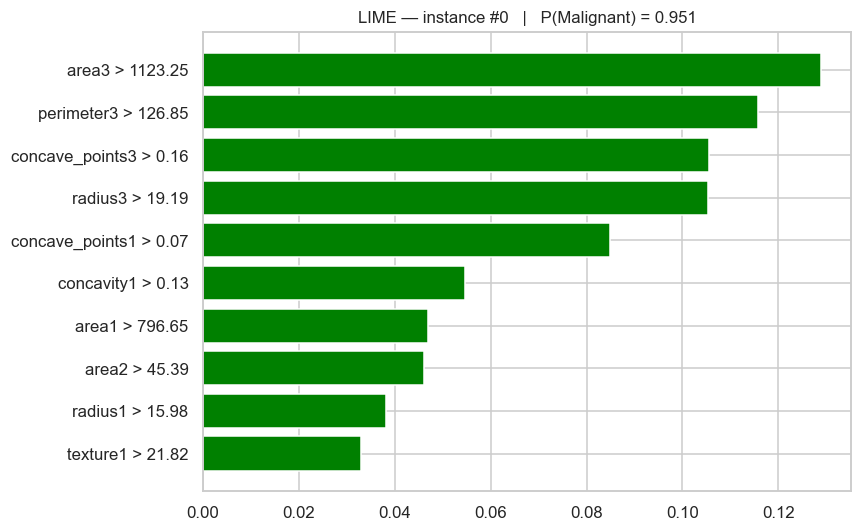

In [14]:
fig = exp.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title(f"LIME — instance #{idx}   |   P(Malignant) = {proba_rf[idx]:.3f}", fontsize=11)
plt.tight_layout(); plt.show()

In [15]:
!pip install -U lime ipywidgets

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# Rich interactive HTML view. Renders inside Jupyter / Colab.
# Some LIME + IPython version combinations break on this call, so we guard it:
# the explanation itself is unaffected, only this rendering widget.
try:
    exp.show_in_notebook(show_table=True, show_all=False)
except Exception as err:
    print(f"[!] Interactive widget unavailable ({type(err).__name__}). Saving to HTML instead.")
    exp.save_to_file("lime_explanation.html")
    print("    -> open 'lime_explanation.html' in a browser.")
    print("    -> the matplotlib figure above shows the same information.")

[!] Interactive widget unavailable (ImportError). Saving to HTML instead.
    -> open 'lime_explanation.html' in a browser.
    -> the matplotlib figure above shows the same information.


### How to read this plot

* **Green / positive weight** → the condition pushed the prediction **towards Malignant**.
* **Red / negative weight** → it pushed **towards Benign**.
* **Bar length** = magnitude of the local contribution, in units of predicted probability.
* The side table shows the instance's **actual feature values** that triggered each condition.

The local surrogate is, approximately:

$$\hat{p}(\text{Malignant}) \;\approx\; b_0 \;+\; \sum_{k=1}^{K} w_k \cdot \mathbb{1}[\text{condition}_k \text{ holds}]$$

⚠️ **Do not over-claim.** These weights are *associational and local*. "`worst perimeter > 125.4` contributed
+0.21" means the model relied on it here — **not** that enlarging the perimeter would cause cancer.
LIME explains the **model**, not the disease.

## 7. Contrastive Analysis — Benign vs Malignant, and a Failure Case

Explaining one instance is a demo. Explaining *contrasts* is analysis.

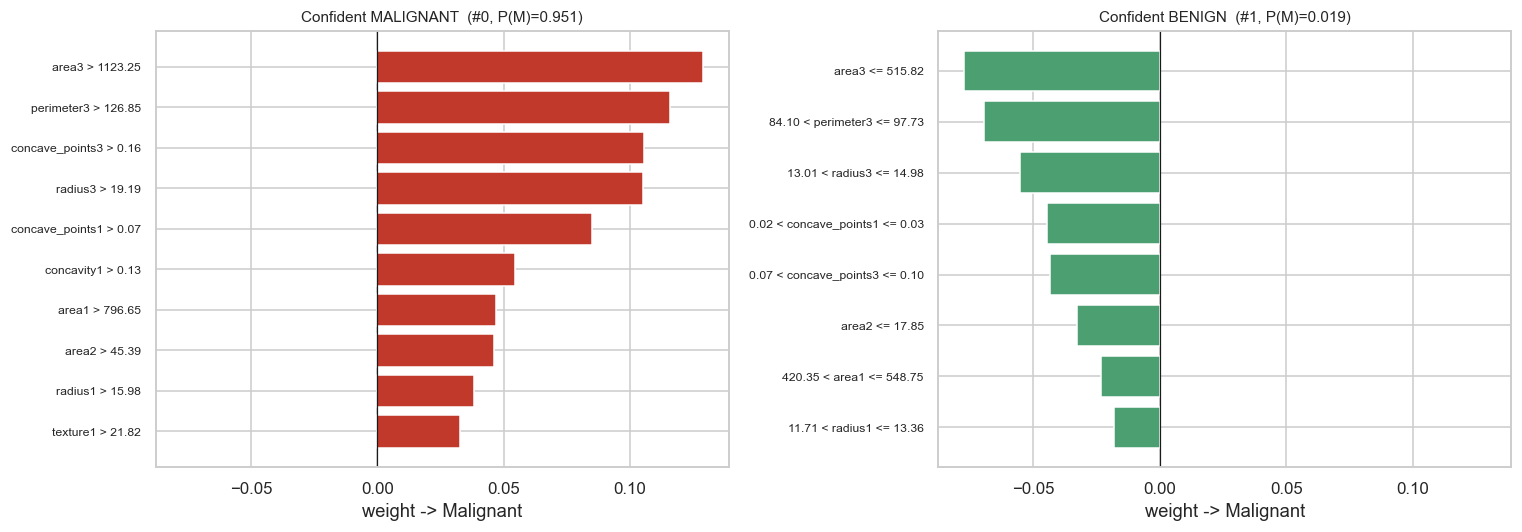

In [17]:
ben_idx = int(np.where((y_test == 0) & (proba_rf < 0.05))[0][0])

exp_ben = explainer.explain_instance(X_test_np[ben_idx], rf.predict_proba,
                                     num_features=8, num_samples=5000, labels=(1,))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, e, i, ttl in [(axes[0], exp,     idx,     "Confident MALIGNANT"),
                      (axes[1], exp_ben, ben_idx, "Confident BENIGN")]:
    items = e.as_list(label=1)[::-1]
    labels = [t for t, _ in items]; vals = [v for _, v in items]
    ax.barh(range(len(vals)), vals,
            color=["#C0392B" if v > 0 else "#4C9F70" for v in vals])
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{ttl}  (#{i}, P(M)={proba_rf[i]:.3f})", fontsize=10)
    ax.set_xlabel("weight -> Malignant")
plt.tight_layout(); plt.show()

Notice the **mirror-image structure**: the same family of features (`worst`-suffixed size and concavity
measures) drives both decisions, but the bins flip sign. That consistency is evidence the model has
learned a coherent rule rather than noise.

In [18]:
# --- Debugging errors with LIME ---
errors = np.where(y_pred_rf != y_test)[0]

if len(errors) == 0:
    print("No misclassifications on this split. Inspecting the most UNCERTAIN prediction instead.")
    target = int(np.argmin(np.abs(proba_rf - 0.5)))
    header = "Most uncertain prediction"
else:
    target = int(errors[np.argmax(np.abs(proba_rf[errors] - 0.5))])   # most confidently wrong
    header = "Most confidently WRONG prediction"

print(f"{header}: instance #{target}")
print(f"  True : {class_names[y_test[target]]}")
print(f"  Pred : {class_names[y_pred_rf[target]]}")
print(f"  P(Malignant) = {proba_rf[target]:.4f}\n")

exp_err = explainer.explain_instance(X_test_np[target], rf.predict_proba,
                                     num_features=10, num_samples=5000, labels=(1,))
for rule, w in exp_err.as_list(label=1):
    print(f"  {rule:<42} {w:>+8.4f}")

Most confidently WRONG prediction: instance #111
  True : Malignant
  Pred : Benign
  P(Malignant) = 0.1581

  texture3 <= 21.48                           -0.0471
  texture1 <= 16.34                           -0.0365
  0.23 < concavity3 <= 0.39                   +0.0215
  1.60 < perimeter2 <= 2.30                   -0.0175
  17.85 < area2 <= 24.75                      -0.0162
  684.55 < area3 <= 1123.25                   +0.0149
  548.75 < area1 <= 796.65                    -0.0134
  0.25 < symmetry3 <= 0.28                    -0.0124
  0.09 < compactness1 <= 0.13                 +0.0124
  14.98 < radius3 <= 19.19                    +0.0119


**Diagnostic questions to ask of a failure explanation:**

1. Are the top features *clinically plausible*, or is the model leaning on a spurious proxy?
2. Do the instance's values sit near a **bin boundary** (e.g. just above the 75th percentile)? Borderline
   cases produce fragile explanations.
3. Do positive and negative weights nearly cancel? That signals genuine ambiguity, not a model bug —
   and argues for abstention / referral to a human rather than retraining.

## 8. Local Fidelity — Is the Explanation Even Trustworthy?

An explanation is worthless if the surrogate $g$ does not actually track $f$ near $x$. LIME exposes three
diagnostics, and **you must report them in any serious write-up**:

| Attribute | Meaning | Healthy value |
|---|---|---|
| `exp.score` | $R^2$ of the weighted ridge fit on the perturbed neighbourhood | > 0.6 |
| `exp.local_pred` | surrogate's prediction at $x$ | close to $f(x)$ |
| `exp.intercept` | $b_0$, the local baseline | — |

In [19]:
print(f"Local surrogate R^2      : {exp.score:.4f}")
print(f"Surrogate prediction g(x): {float(np.ravel(exp.local_pred)[0]):.4f}")
print(f"Black-box  f(x)          : {rf.predict_proba(x.reshape(1, -1))[0, 1]:.4f}")
print(f"Local intercept b0       : {exp.intercept[1]:.4f}")

gap = abs(float(np.ravel(exp.local_pred)[0]) - rf.predict_proba(x.reshape(1,-1))[0,1])
print("\nVerdict:", "trustworthy" if (exp.score > 0.6 and gap < 0.15)
      else "treat with caution — poor local fit")

Local surrogate R^2      : 0.6380
Surrogate prediction g(x): 1.0090


Black-box  f(x)          : 0.9509
Local intercept b0       : 0.2497

Verdict: trustworthy


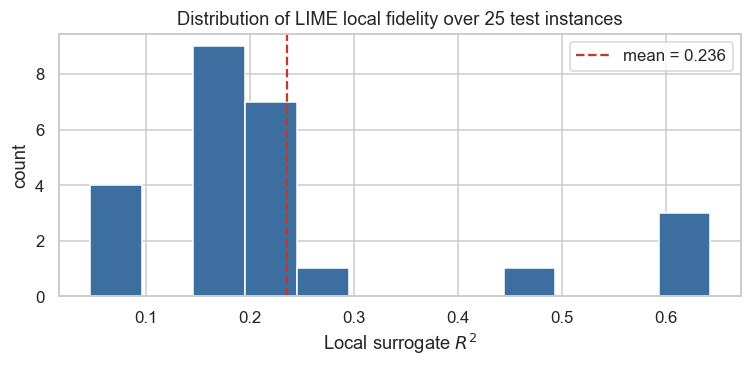

min=0.047  median=0.195  max=0.643


In [20]:
# Fidelity is not uniform across the input space. Measure it over a sample of test points.
rng = np.random.RandomState(SEED)
sample = rng.choice(len(X_test_np), size=25, replace=False)

scores = []
for i in sample:
    e = explainer.explain_instance(X_test_np[i], rf.predict_proba,
                                   num_features=8, num_samples=2000, labels=(1,))
    scores.append(e.score)
scores = np.array(scores)

plt.figure(figsize=(7, 3.5))
plt.hist(scores, bins=12, color="#3C6E9F", edgecolor="white")
plt.axvline(scores.mean(), color="#C0392B", ls="--",
            label=f"mean = {scores.mean():.3f}")
plt.xlabel("Local surrogate $R^2$"); plt.ylabel("count")
plt.title("Distribution of LIME local fidelity over 25 test instances")
plt.legend(); plt.tight_layout(); plt.show()

print(f"min={scores.min():.3f}  median={np.median(scores):.3f}  max={scores.max():.3f}")

### Interpreting a low median $R^2$

You will probably find the median $R^2$ is **well below 0.6** — much lower than for the confident instance
in the previous cell. This is not a bug, and it is one of the most instructive results in this notebook.
Three things are going on:

1. **Saturated predictions.** This model is very accurate, so for most test points $f(z) \approx 1$ or
   $\approx 0$ across the whole neighbourhood. With almost no variance in the target, $R^2$ collapses
   even though the surrogate's *absolute* error is tiny. **Always read $R^2$ alongside
   $|g(x) - f(x)|$** — a flat neighbourhood is easy to approximate but scores badly.
2. **Fewer samples.** We used `num_samples=2000` here versus 5000 above. Fidelity rises with sample size.
3. **Genuinely non-linear regions.** Some points sit near a complex decision boundary where no linear
   surrogate can fit well. Those explanations really should be distrusted.

**Exercise:** re-run the cell with `num_samples=10000` and additionally record
$|g(x) - f(x)|$. Which of the three causes above dominates for this dataset?

## 9. Stability — The Experiment Most Reports Omit

LIME samples randomly. Run it twice on the *same* instance with a *different* seed and you may get
different weights. If your explanation flips between runs, you cannot show it to a clinician.

We run the explainer **10 times** on one instance and measure the spread of each feature's weight.

In [21]:
N_RUNS = 10
runs = []
for r in range(N_RUNS):
    e = lime.lime_tabular.LimeTabularExplainer(
            X_train_np, feature_names=feature_names, class_names=class_names,
            mode="classification", discretize_continuous=True, random_state=100 + r
        ).explain_instance(x, rf.predict_proba, num_features=10,
                           num_samples=5000, labels=(1,))
    runs.append(dict(e.as_list(label=1)))

stab = pd.DataFrame(runs).fillna(0.0)
summary = (pd.DataFrame({"mean": stab.mean(), "std": stab.std(),
                         "appeared_in_runs": (stab != 0).sum()})
             .sort_values("mean", key=np.abs, ascending=False))
summary["CV_%"] = (summary["std"].abs() / summary["mean"].abs().replace(0, np.nan) * 100).round(1)
display(summary.round(4))

,mean,std,appeared_in_runs,CV_%
area3 > 1123.25,0.1266,0.0024,10,1.9
perimeter3 > 126.85,0.1234,0.0015,10,1.2
concave_points3 > 0.16,0.1056,0.0023,10,2.2
radius3 > 19.19,0.1022,0.0034,10,3.4
concave_points1 > 0.07,0.0819,0.0026,10,3.2
concavity1 > 0.13,0.0501,0.0021,10,4.1
radius1 > 15.98,0.0486,0.0028,10,5.7
area2 > 45.39,0.0486,0.0030,10,6.2
area1 > 796.65,0.0461,0.0022,10,4.8
symmetry3 > 0.32,0.0302,0.0160,8,53.0


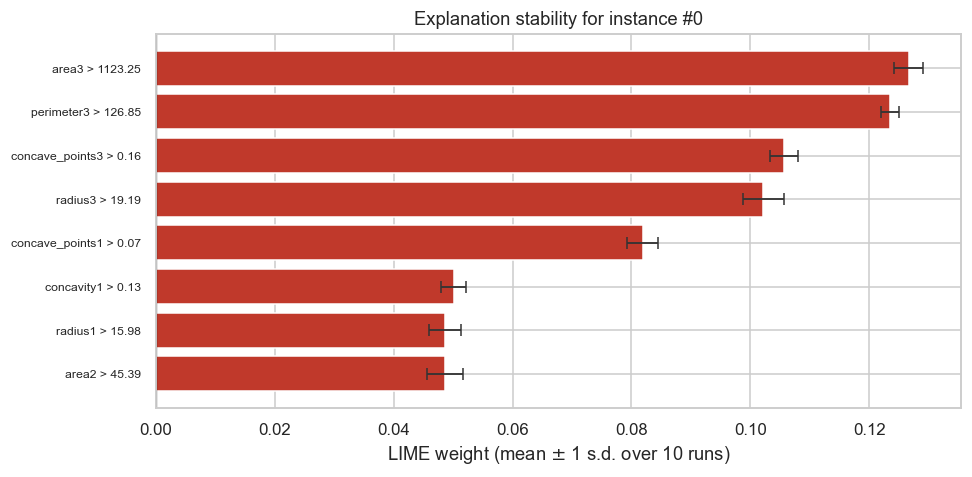

Features appearing in ALL 10 runs (robust):
  area3 > 1123.25
  perimeter3 > 126.85
  concave_points3 > 0.16
  radius3 > 19.19
  concave_points1 > 0.07
  concavity1 > 0.13
  radius1 > 15.98
  area2 > 45.39


In [22]:
top = summary.head(8).iloc[::-1]
plt.figure(figsize=(9, 4.5))
plt.barh(range(len(top)), top["mean"], xerr=top["std"], capsize=4,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in top["mean"]],
         error_kw=dict(ecolor="#333", lw=1.2))
plt.yticks(range(len(top)), top.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("LIME weight (mean $\\pm$ 1 s.d. over 10 runs)")
plt.title(f"Explanation stability for instance #{idx}")
plt.tight_layout(); plt.show()

print("Features appearing in ALL 10 runs (robust):")
print("  " + "\n  ".join(summary.index[summary["appeared_in_runs"] == N_RUNS][:8]))

**Reporting rule for your lab report / thesis:** never present a single LIME run. Report
**mean ± s.d. over ≥ 10 runs**, and state how often each feature survived. Features with a small
`appeared_in_runs` count are artefacts of sampling, not findings.

**Levers that improve stability:** raise `num_samples` (5000 → 15000), reduce `num_features`,
fix `random_state`, or drop one member of each near-collinear feature group (`radius`/`perimeter`/`area`).

## 10. From Local to Global — SP-LIME (Submodular Pick)

One explanation covers one patient. To audit a whole model you would need 143 explanations.
**SP-LIME** selects a small, *non-redundant* set of instances whose explanations jointly cover the
most feature-importance mass — a greedy maximisation of a submodular coverage function
(which guarantees $\geq (1 - 1/e) \approx 63\%$ of the optimum).

In [23]:
from lime import submodular_pick

# NOTE (common bug): SubmodularPick defaults to top_labels=1, so each explanation
# only stores ITS OWN predicted label. A benign instance then has no label 1 and
# `as_list(label=1)` raises KeyError. Pass top_labels=None + labels=(1,) to force
# every instance to be explained w.r.t. the SAME class -> comparable weights.
sp = submodular_pick.SubmodularPick(
    explainer, X_test_np, rf.predict_proba,
    num_features=8, num_exps_desired=3, sample_size=20,
    top_labels=None, labels=(1,))

print(f"SP-LIME selected {len(sp.sp_explanations)} representative instances "
      f"out of {len(X_test_np)} test cases.\n")

for j, e in enumerate(sp.sp_explanations, 1):
    print(f"--- Representative case {j} ---")
    for rule, w in e.as_list(label=1)[:5]:
        print(f"    {rule:<40} {w:>+8.4f}")
    print()

SP-LIME selected 3 representative instances out of 143 test cases.

--- Representative case 1 ---
    area3 <= 515.82                           -0.0795
    perimeter3 <= 84.10                       -0.0713
    radius3 <= 13.01                          -0.0573
    concave_points3 <= 0.07                   -0.0538
    texture3 <= 21.48                         -0.0468

--- Representative case 2 ---
    515.82 < area3 <= 684.55                  -0.0690
    13.01 < radius3 <= 14.98                  -0.0595
    84.10 < perimeter3 <= 97.73               -0.0586
    0.07 < concave_points3 <= 0.10            -0.0569
    texture3 > 30.14                          +0.0490

--- Representative case 3 ---
    area3 > 1123.25                           +0.1294
    perimeter3 > 126.85                       +0.1267
    radius3 > 19.19                           +0.1038
    concave_points1 > 0.07                    +0.0755
    radius1 > 15.98                           +0.0494



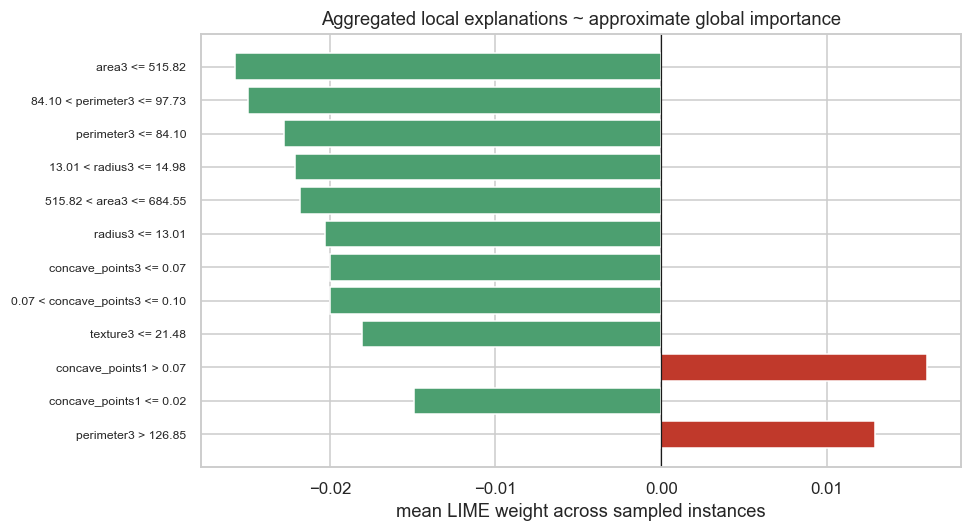

In [24]:
# Aggregate all explanations SP-LIME computed -> an approximate global view
W = pd.DataFrame([dict(e.as_list(label=1)) for e in sp.explanations]).fillna(0)
agg = W.mean().sort_values(key=np.abs, ascending=False).head(12)[::-1]

plt.figure(figsize=(9, 5))
plt.barh(range(len(agg)), agg.values,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in agg.values])
plt.yticks(range(len(agg)), agg.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("mean LIME weight across sampled instances")
plt.title("Aggregated local explanations ~ approximate global importance")
plt.tight_layout(); plt.show()

## 11. Cross-Check: LIME vs. Permutation Importance

A useful validation habit — do the aggregated **local** explanations agree with a genuine **global**
method? Agreement raises confidence; disagreement is a finding worth investigating.

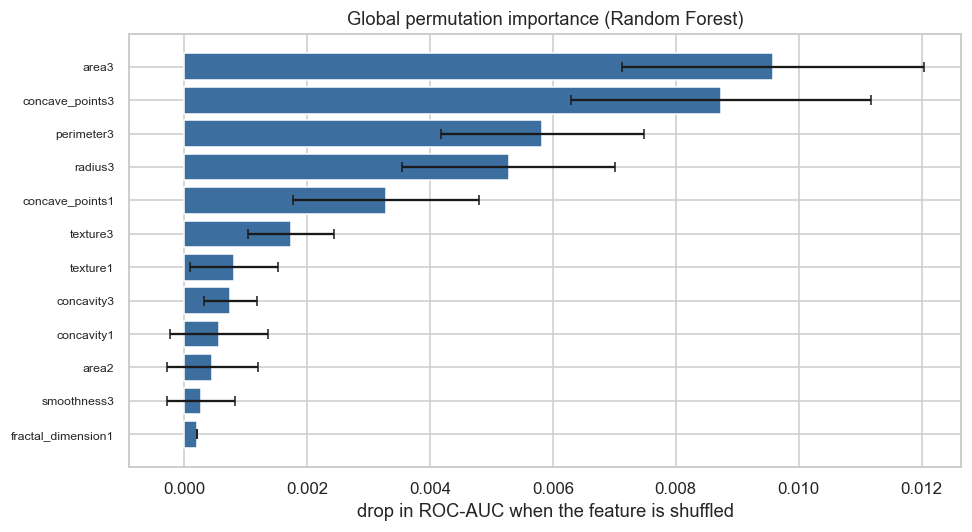

Top-6 GLOBAL (permutation) :
   area3                        0.0096
   concave_points3              0.0087
   perimeter3                   0.0058
   radius3                      0.0053
   concave_points1              0.0033
   texture3                     0.0017

Top-6 aggregated LOCAL (LIME) :
   area3 <= 515.82                          -0.0257
   84.10 < perimeter3 <= 97.73              -0.0250
   perimeter3 <= 84.10                      -0.0227
   13.01 < radius3 <= 14.98                 -0.0221
   515.82 < area3 <= 684.55                 -0.0218
   radius3 <= 13.01                         -0.0203


In [25]:
perm = permutation_importance(rf, X_test_np, y_test, n_repeats=10,
                              random_state=SEED, n_jobs=-1, scoring="roc_auc")

order = np.argsort(perm.importances_mean)[-12:]
plt.figure(figsize=(9, 5))
plt.barh(range(len(order)), perm.importances_mean[order],
         xerr=perm.importances_std[order], color="#3C6E9F", capsize=3)
plt.yticks(range(len(order)), [feature_names[i] for i in order], fontsize=8)
plt.xlabel("drop in ROC-AUC when the feature is shuffled")
plt.title("Global permutation importance (Random Forest)")
plt.tight_layout(); plt.show()

print("Top-6 GLOBAL (permutation) :")
for i in order[::-1][:6]:
    print(f"   {feature_names[i]:<28} {perm.importances_mean[i]:.4f}")

print("\nTop-6 aggregated LOCAL (LIME) :")
for rule, w in agg.iloc[::-1].head(6).items():
    print(f"   {rule:<40} {w:+.4f}")

> Expect **partial** agreement. Permutation importance measures *"how much does test performance
> degrade without this feature?"*; LIME measures *"how much did this feature move THIS prediction?"*.
> They answer different questions, so a rank correlation of ~0.5–0.7 is normal and healthy.
> A near-zero correlation would suggest the local surrogates are fitting noise — go back to Section 8.

## 12. Limitations of LIME, and LIME vs SHAP

### Known weaknesses

| # | Limitation | Practical consequence |
|---|---|---|
| 1 | **Instability** — random sampling | Different runs → different explanations (Section 9) |
| 2 | **Kernel width $\sigma$ is arbitrary** | The default heuristic $\sigma = 0.75\sqrt{d}$ has no theoretical basis; changing it can reverse conclusions |
| 3 | **"Local" is undefined** | No principled answer to *how large* the neighbourhood should be |
| 4 | **Correlated features** | Perturbation creates off-manifold, physically impossible samples; credit is split arbitrarily |
| 5 | **No guarantees** | Contributions do not sum to the prediction (unlike Shapley values) |
| 6 | **Adversarially foolable** | Slack et al. (2020) showed a biased model can be built that hides its bias from LIME |
| 7 | **Cost** | One explanation = `num_samples` model calls; 5000 per instance is expensive at scale |

### Comparison

| Criterion | **LIME** | **SHAP (KernelSHAP / TreeSHAP)** |
|---|---|---|
| Theoretical basis | Local surrogate regression | Shapley values (cooperative game theory) |
| Axioms | none | efficiency, symmetry, dummy, additivity |
| Additivity | ✗ | ✓ contributions sum to $f(x) - \mathbb{E}[f]$ |
| Speed | fast per instance | slow (KernelSHAP); very fast for trees (TreeSHAP) |
| Stability | low–moderate | high |
| Global view | via SP-LIME | native (summary / beeswarm plots) |
| Ease of teaching | ✓ very intuitive | steeper |

**Rule of thumb.** Use LIME for rapid, intuitive, model-agnostic debugging and for text/image data.
Use SHAP when you need theoretical guarantees, additivity, or a defensible audit trail. Best practice
in a thesis: **report both** and discuss where they disagree.

# Assignment: Local Model Explanations Using LIME

## Dataset: Adult / Census Income Dataset

### Objective

Apply **Local Interpretable Model-agnostic Explanations (LIME)** to explain predictions made by a machine-learning classification model on a tabular dataset.

You must use the **Adult/Census Income dataset**, where the objective is to predict whether an individual's annual income is above or below a specified income threshold.

---

# Part A — Dataset Preparation

1. Load the Adult Income dataset and display:
   - Number of instances
   - Number of features
   - Feature names
   - Target variable
   - Numerical features
   - Categorical features

2. Check the dataset for:
   - Missing values
   - Duplicate records
   - Invalid or unknown categorical values
   - Class imbalance

3. Perform appropriate preprocessing for numerical and categorical features.

4. Explain why categorical features require special handling when using `LimeTabularExplainer`.

---

# Part B — Machine Learning Model

5. Split the dataset into training and testing sets using a suitable stratified split.

6. Train the following classification models:

   - Random Forest
   - Logistic Regression

7. Evaluate both models using:

   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Confusion matrix

8. Compare the performance of the two models.

9. Identify which model should be considered the **black-box model** for the LIME analysis and explain why.

---

# Part C — Applying LIME

10. Create a `LimeTabularExplainer` using the training data.

11. Correctly specify:

```python
feature_names
class_names
categorical_features
categorical_names

# Part D — Interpretation of LIME Explanations

For each of the three selected instances:

### 16. Identify the Top Five Positive Contributors

Identify the **top five features with positive LIME weights** for each instance.

Explain how these features support the predicted class.

---

### 17. Identify the Top Five Negative Contributors

Identify the **top five features with negative LIME weights** for each instance.

Explain how these features oppose or reduce the likelihood of the predicted class.

---

### 18. Interpret the Important Features

Explain in simple language why each of the important features influenced the prediction.

For each feature, discuss:

- Feature value or condition
- LIME weight
- Direction of influence
- Effect on the prediction

---

### 19. Interpretation of a Positive LIME Weight

Answer the following question:

> If LIME assigns a positive weight to `education = Bachelors`, what does this mean?

Explain the meaning of the positive LIME weight in the context of the predicted class.

---

### 20. Difference Between Feature Importance, LIME Weight, and Prediction Probability

Explain the difference between:

- **Feature importance**
- **LIME weight**
- **Model prediction probability**

Discuss how each one should be interpreted and how they are different from one another.

---

### 21. If–Then Style Explanation

Select one of the three instances and convert its LIME explanation into an **if–then style explanation**.

For example:

> **If** the individual's education level is within a particular category and other important feature conditions are satisfied, **then** these conditions contribute toward the model predicting the selected income class.

Use the actual LIME output from your experiment to construct the explanation.

---

# Part E — Misclassification Analysis

### 22. Select an Incorrectly Classified Instance

Select at least **one incorrectly classified test instance**.

Report:

- Actual class
- Predicted class
- Prediction probability
- Important feature values

---

### 23. Generate the LIME Explanation

Generate a LIME explanation for the incorrectly classified instance.

Display the top contributing features and their LIME weights.

---

### 24. Identify the Main Contributors to the Incorrect Prediction

Identify the features that contributed most strongly to the incorrect prediction.

Separate the features into:

- Positive contributors
- Negative contributors

Explain their influence on the model's prediction.

---

### 25. Analyze the Model Error

Discuss whether the LIME explanation provides a possible reason for the model's incorrect prediction.

Consider:

- Which features strongly influenced the prediction?
- Did these features push the model toward the wrong class?
- Was the prediction probability close to the decision boundary?
- Are there conflicting feature contributions?

---

### 26. Can LIME Prove Causation?

Answer the following question:

> Can LIME prove that a particular feature caused the model to make an error? Explain your answer.

Discuss the difference between:

- **Model association**
- **Feature contribution**
- **Causal relationship**

---

# Part F — LIME Stability

LIME uses randomly generated perturbed samples to construct a local explanation. Therefore, the same instance can produce slightly different explanations across different runs.

### 27. Run LIME Multiple Times

Select one test instance and run LIME **10 times** using the same model and instance.

Record the LIME explanation produced during each run.

---

### 28. Record LIME Weights

Record the LIME weights of the **top five features** for every run.

Create a table similar to:

| Run | Feature 1 | Feature 2 | Feature 3 | Feature 4 | Feature 5 |
|---:|---:|---:|---:|---:|---:|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |
| 9 | | | | | |
| 10 | | | | | |

---

### 29. Calculate Stability Measures

Calculate the following for the important features:

- **Mean LIME weight**
- **Standard deviation**
- **Minimum LIME weight**
- **Maximum LIME weight**
- **Number of times the feature appears in the top five**

---

### 30. Visualize LIME Stability

Create a graph showing:

**Feature vs. Mean LIME Weight ± Standard Deviation**

The graph should allow you to compare both:

- Average feature contribution
- Variation in the feature contribution

---

### 31. Identify Stable and Unstable Features

Based on the stability analysis, identify:

1. The most stable feature.
2. The least stable feature.
3. The feature with the highest average contribution.
4. The feature with the largest variation in LIME weight.

---

### 32. Explain Variation in LIME

Explain why LIME explanations may change between different runs.

Consider the role of:

- Random perturbations
- Number of samples
- Local neighbourhood
- Kernel width
- Model complexity

---

### 33. Increase the Number of Samples

Repeat the LIME stability experiment using a larger value of `num_samples`.

Compare the explanations obtained using different numbers of perturbed samples.

---

### 34. Compare Different `num_samples` Values

Compare the stability obtained using:

```text
num_samples = 1,000
num_samples = 5,000
num_samples = 10,000

---
# Assignment Solution

The sections below implement Parts A-F of the assignment above, using the **Adult / Census Income**
dataset (UCI ID = 2). Each numbered item corresponds to the matching question above.

In [26]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_score, recall_score, f1_score


## Part A -- Dataset Preparation (Q1-Q4)

In [27]:
def load_adult_income(verbose=True):
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=2)                      # 2 = Adult / Census Income
        Xa = ds.data.features.copy()
        ya_raw = ds.data.targets.iloc[:, 0]
        source = "UCI ML Repository (live fetch, id=2)"
        if verbose:
            print(ds.metadata["name"], "|", ds.metadata["abstract"][:90], "...")
    except Exception as e:
        from sklearn.datasets import fetch_openml
        if verbose:
            print(f"[!] Live UCI fetch unavailable ({type(e).__name__}). Falling back to OpenML \'adult\'.")
        d = fetch_openml(name="adult", version=2, as_frame=True)
        Xa = d.data.copy()
        Xa.columns = [c.replace("_", "-") for c in Xa.columns]
        ya_raw = d.target
        source = "OpenML \'adult\' (version 2)"

    # target: strip the trailing "." used in the UCI test-file rows, encode >50K = 1
    ya = (ya_raw.astype(str).str.strip().str.rstrip(".") == ">50K").astype(int).to_numpy()

    # fnlwgt is a census sampling weight, not an attribute of the individual -> drop it
    if "fnlwgt" in Xa.columns:
        Xa = Xa.drop(columns=["fnlwgt"])

    # strip stray whitespace from string cells without turning real NaNs into the string "nan"
    for c in Xa.select_dtypes(include="object").columns:
        Xa[c] = Xa[c].map(lambda v: v.strip() if isinstance(v, str) else v)

    return Xa, ya, source


X_ad, y_ad, SOURCE_AD = load_adult_income()

numeric_cols_ad     = X_ad.select_dtypes(include=np.number).columns.tolist()
categorical_cols_ad = X_ad.select_dtypes(exclude=np.number).columns.tolist()

print("\nSource               :", SOURCE_AD)
print("Instances            :", X_ad.shape[0])
print("Features             :", X_ad.shape[1])
print("Feature names        :", X_ad.columns.tolist())
print("Target                : income (0 = <=50K, 1 = >50K)")
print("Numerical features    :", numeric_cols_ad)
print("Categorical features  :", categorical_cols_ad)
X_ad.head()


Adult | Predict whether annual income of an individual exceeds $50K/yr based on census data. Also  ...

Source               : UCI ML Repository (live fetch, id=2)
Instances            : 48842
Features             : 13
Feature names        : ['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
Target                : income (0 = <=50K, 1 = >50K)
Numerical features    : ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features  : ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


### Q2 -- Missing values, duplicates, invalid categorical values, class imbalance

=== Missing values (NaN) per column ===
workclass         963
occupation        966
native-country    274
dtype: int64

=== '?' (unknown) markers per categorical column ===
  workclass       : 1836
  occupation      : 1843
  native-country  : 583

Duplicate records      : 7309

=== Class balance ===
<=50K    37155
>50K     11687
Name: count, dtype: int64
>50K share: 23.9%  (imbalance ratio ~ 3.18:1)


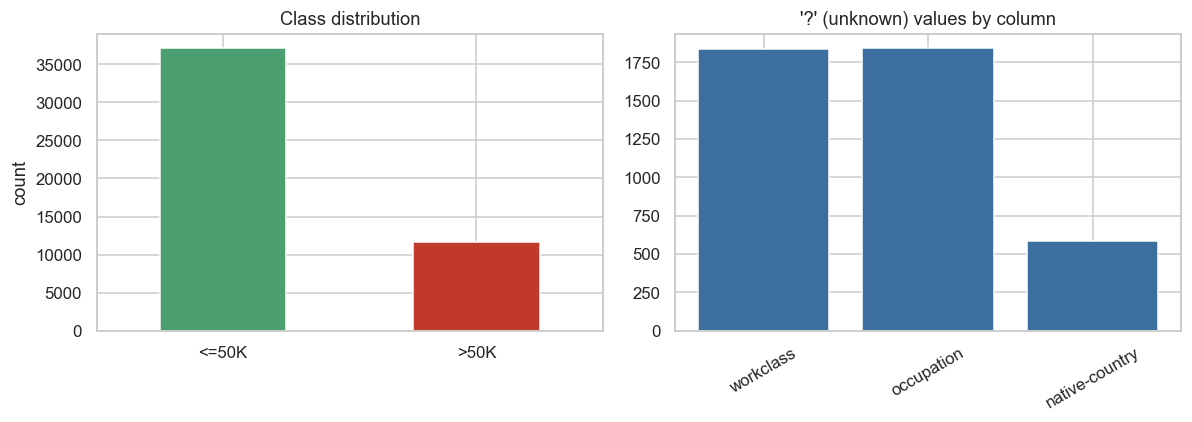

In [28]:
print("=== Missing values (NaN) per column ===")
na_counts = X_ad.isna().sum()
print(na_counts[na_counts > 0] if na_counts.sum() else "None")

print("\n=== \'?\' (unknown) markers per categorical column ===")
unk_counts = {c: int((X_ad[c] == "?").sum()) for c in categorical_cols_ad}
for c, n in unk_counts.items():
    if n:
        print(f"  {c:<16}: {n}")

n_dup = int(X_ad.duplicated().sum())
print(f"\nDuplicate records      : {n_dup}")

print("\n=== Class balance ===")
counts_ad = pd.Series(y_ad).map({0: "<=50K", 1: ">50K"}).value_counts()
print(counts_ad)
print(f">50K share: {100*y_ad.mean():.1f}%  (imbalance ratio ~ {counts_ad.max()/counts_ad.min():.2f}:1)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts_ad.plot(kind="bar", ax=axes[0], color=["#4C9F70", "#C0392B"], rot=0)
axes[0].set_title("Class distribution"); axes[0].set_ylabel("count")

nz = {c: n for c, n in unk_counts.items() if n}
axes[1].bar(nz.keys(), nz.values(), color="#3C6E9F")
axes[1].set_title("\'?\' (unknown) values by column"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


### Q3 -- Preprocessing

In [29]:
X_clean = X_ad.copy()
for c in categorical_cols_ad:
    X_clean[c] = X_clean[c].replace("?", np.nan).fillna("Unknown")

before = len(X_clean)
mask_dup = X_clean.duplicated()
X_clean = X_clean.loc[~mask_dup].reset_index(drop=True)
y_clean = y_ad[~mask_dup.to_numpy()]
print(f"Dropped {before - len(X_clean)} duplicate rows -> {len(X_clean)} rows remain")

feature_names_ad = X_clean.columns.tolist()
label_encoders_ad = {}
X_enc = X_clean.copy()
for c in categorical_cols_ad:
    le = LabelEncoder()
    X_enc[c] = le.fit_transform(X_clean[c])
    label_encoders_ad[c] = le

categorical_features_ad = [feature_names_ad.index(c) for c in categorical_cols_ad]
categorical_names_ad = {feature_names_ad.index(c): label_encoders_ad[c].classes_.tolist()
                        for c in categorical_cols_ad}

X_ad_np = X_enc.to_numpy(dtype=float)
class_names_ad = ["<=50K", ">50K"]

print("Final feature matrix :", X_ad_np.shape)
print("Categorical indices  :", categorical_features_ad)
X_clean.head()


Dropped 7403 duplicate rows -> 41439 rows remain
Final feature matrix : (41439, 13)
Categorical indices  : [1, 2, 4, 5, 6, 7, 8, 12]


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


### Q4 -- Why categorical features need special handling in `LimeTabularExplainer`

By default LIME perturbs a *continuous* feature by sampling from a Normal distribution fitted on the
training column (mean/std) and reports discretised bins as ordered thresholds (e.g. `age > 42.00`).
A categorical column such as `workclass` or `native-country` has no such ordering -- the integer codes
produced by `LabelEncoder` (0, 1, 2, ...) are arbitrary labels, not a scale. Sampling from
$\mathcal{N}(\mu,\sigma)$ over them would generate nonsense values (e.g. code 2.7, which maps to nothing)
and the reported rule would look like `workclass > 2.7`, which is meaningless for a nominal attribute.

`LimeTabularExplainer` handles this correctly only if you tell it which columns are categorical:

* **`categorical_features`** -- the column indices to treat as categorical rather than continuous, so LIME
  perturbs them by sampling from their **empirical training-set frequency** instead of a Gaussian.
* **`categorical_names`** -- a mapping from each categorical index to its list of human-readable labels, so
  the explanation prints `workclass = Private` instead of `workclass = 2`.

Without this, LIME would (a) generate physically impossible synthetic rows for categorical columns, and
(b) report uninterpretable numeric thresholds on what is really a nominal attribute.

## Part B -- Machine Learning Model (Q5-Q9)

In [30]:
Xtr_ad, Xte_ad, ytr_ad, yte_ad = train_test_split(
    X_ad_np, y_clean, test_size=0.25, random_state=SEED, stratify=y_clean)

print(f"Train: {Xtr_ad.shape[0]} samples ({100*ytr_ad.mean():.1f}% >50K)")
print(f"Test : {Xte_ad.shape[0]} samples ({100*yte_ad.mean():.1f}% >50K)")


Train: 31079 samples (23.9% >50K)
Test : 10360 samples (23.9% >50K)


In [31]:
onehot_ct_ad = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_ad)],
    remainder=StandardScaler()          # numeric columns pass through, then get scaled
)

logreg_ad = Pipeline([
    ("prep", onehot_ct_ad),
    ("clf", LogisticRegression(max_iter=5000, random_state=SEED))
])

rf_ad = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    n_jobs=-1, random_state=SEED)

logreg_ad.fit(Xtr_ad, ytr_ad)
rf_ad.fit(Xtr_ad, ytr_ad)
print("Both models trained.")


Both models trained.



Logistic Regression
Accuracy : 0.8578
Precision: 0.7431
Recall   : 0.6206
F1-score : 0.6763
ROC-AUC  : 0.9113
              precision    recall  f1-score   support

       <=50K      0.886     0.932     0.909      7880
        >50K      0.743     0.621     0.676      2480

    accuracy                          0.858     10360
   macro avg      0.815     0.777     0.793     10360
weighted avg      0.852     0.858     0.853     10360




Random Forest
Accuracy : 0.8726
Precision: 0.7757
Recall   : 0.6581
F1-score : 0.7120
ROC-AUC  : 0.9236
              precision    recall  f1-score   support

       <=50K      0.897     0.940     0.918      7880
        >50K      0.776     0.658     0.712      2480

    accuracy                          0.873     10360
   macro avg      0.836     0.799     0.815     10360
weighted avg      0.868     0.873     0.869     10360



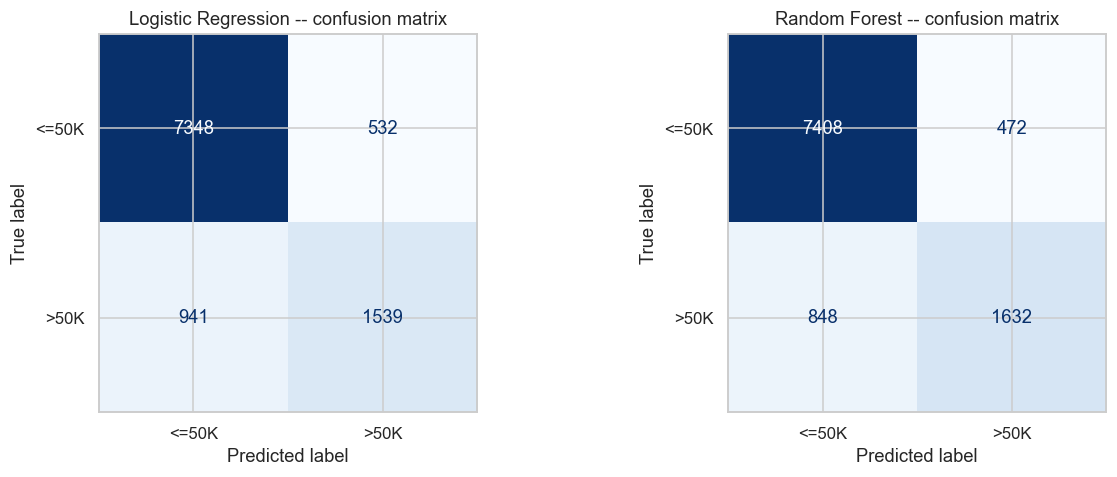

In [32]:
def pick_confident(mask, want_high, proba):
    candidates = np.where(mask)[0]
    if len(candidates) == 0:
        return int(np.argmax(proba)) if want_high else int(np.argmin(proba))
    return int(candidates[0])


def evaluate_ad(model, name):
    y_pred  = model.predict(Xte_ad)
    y_proba = model.predict_proba(Xte_ad)[:, 1]
    acc  = accuracy_score(yte_ad, y_pred)
    prec = precision_score(yte_ad, y_pred)
    rec  = recall_score(yte_ad, y_pred)
    f1   = f1_score(yte_ad, y_pred)
    auc  = roc_auc_score(yte_ad, y_proba)
    print(f"\n{'='*58}\n{name}\n{'='*58}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(yte_ad, y_pred, target_names=class_names_ad, digits=3))
    return dict(model=name, accuracy=acc, precision=prec, recall=rec, f1=f1, roc_auc=auc), y_pred, y_proba

res_lr, y_pred_lr_ad, proba_lr_ad = evaluate_ad(logreg_ad, "Logistic Regression")
res_rf, y_pred_rf_ad, proba_rf_ad = evaluate_ad(rf_ad,     "Random Forest")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(yte_ad, y_pred_lr_ad),
                       display_labels=class_names_ad).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression -- confusion matrix")
ConfusionMatrixDisplay(confusion_matrix(yte_ad, y_pred_rf_ad),
                       display_labels=class_names_ad).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Random Forest -- confusion matrix")
plt.tight_layout(); plt.show()


In [33]:
compare_ad = pd.DataFrame([res_lr, res_rf]).set_index("model").round(4)
display(compare_ad)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    w = compare_ad[metric].idxmax()
    print(f"  higher {metric:<10}: {w} ({compare_ad[metric].max():.4f})")


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.8578,0.7431,0.6206,0.6763,0.9113
Random Forest,0.8726,0.7757,0.6581,0.7120,0.9236


  higher accuracy  : Random Forest (0.8726)
  higher precision : Random Forest (0.7757)
  higher recall    : Random Forest (0.6581)
  higher f1        : Random Forest (0.7120)
  higher roc_auc   : Random Forest (0.9236)


### Q9 -- Which model is the black-box model, and why?

**The Random Forest is the black-box model.** It is an ensemble of 400 decision trees; a prediction is
the *average* of hundreds of tree paths, so there is no single coefficient or rule that summarises "why"
a given prediction was made -- the decision logic is distributed across thousands of split conditions.

**Logistic Regression is the interpretable baseline.** Its fitted coefficients are themselves a global,
human-readable explanation (`coef_[j]` = the effect of feature `j`, holding the others fixed), so it needs
no post-hoc explanation method at all.

This choice is structural (about model *form*), independent of which model happens to score higher above
-- LIME is only useful for the model whose internal reasoning is otherwise opaque.

## Part C -- Applying LIME (Q10-Q15)

In [34]:
explainer_ad = lime.lime_tabular.LimeTabularExplainer(
    training_data          = Xtr_ad,
    feature_names           = feature_names_ad,
    class_names             = class_names_ad,
    categorical_features    = categorical_features_ad,
    categorical_names       = categorical_names_ad,
    mode                    = "classification",
    discretize_continuous   = True,
    discretizer             = "quartile",
    random_state            = SEED,
    verbose                 = False
)
print("Adult-income explainer ready.", Xtr_ad.shape[0], "training rows.")


Adult-income explainer ready. 31079 training rows.


In [35]:
hi_pos_idx = pick_confident((yte_ad == 1) & (proba_rf_ad > 0.9), True,  proba_rf_ad)
hi_neg_idx = pick_confident((yte_ad == 0) & (proba_rf_ad < 0.1), False, proba_rf_ad)
border_idx = int(np.argmin(np.abs(proba_rf_ad - 0.5)))

selected_ad = {"High-confidence >50K": hi_pos_idx,
               "High-confidence <=50K": hi_neg_idx,
               "Borderline / uncertain": border_idx}

for label, i in selected_ad.items():
    print(f"{label:<24} -> idx {i:<5} true={class_names_ad[yte_ad[i]]:<6} "
          f"pred={class_names_ad[y_pred_rf_ad[i]]:<6} P(>50K)={proba_rf_ad[i]:.4f}")


High-confidence >50K     -> idx 15    true=>50K   pred=>50K   P(>50K)=0.9959
High-confidence <=50K    -> idx 1     true=<=50K  pred=<=50K  P(>50K)=0.0000
Borderline / uncertain   -> idx 6740  true=<=50K  pred=<=50K  P(>50K)=0.5000



=== High-confidence >50K (idx 15, P(>50K)=0.996) ===


  capital-gain <= 0.00                    -0.5779  -> <=50K
  education-num > 13.00                   +0.1843  -> >50K
  marital-status=Married-civ-spouse       +0.1045  -> >50K
  relationship=Husband                    +0.0982  -> >50K
  capital-loss > 0.00                     +0.0960  -> >50K
  hours-per-week > 45.00                  +0.0697  -> >50K
  occupation=Exec-managerial              +0.0369  -> >50K
  sex=Male                                +0.0170  -> >50K
  workclass=Private                       +0.0042  -> >50K
  28.00 < age <= 38.00                    +0.0020  -> >50K



=== High-confidence <=50K (idx 1, P(>50K)=0.000) ===
  capital-gain <= 0.00                    -0.5860  -> <=50K
  education-num <= 9.00                   -0.0953  -> <=50K
  capital-loss <= 0.00                    -0.0878  -> <=50K
  marital-status=Never-married            -0.0750  -> <=50K
  relationship=Own-child                  -0.0673  -> <=50K
  race=Black                              -0.0190  -> <=50K
  sex=Male                                +0.0171  -> >50K
  native-country=United-States            -0.0135  -> <=50K
  occupation=Transport-moving             -0.0090  -> <=50K
  38.00 < hours-per-week <= 40.00         -0.0070  -> <=50K

=== Borderline / uncertain (idx 6740, P(>50K)=0.500) ===
  capital-gain <= 0.00                    -0.5909  -> <=50K
  relationship=Husband                    +0.0946  -> >50K
  marital-status=Married-civ-spouse       +0.0927  -> >50K
  capital-loss <= 0.00                    -0.0854  -> <=50K
  hours-per-week > 45.00                  +0.0709  

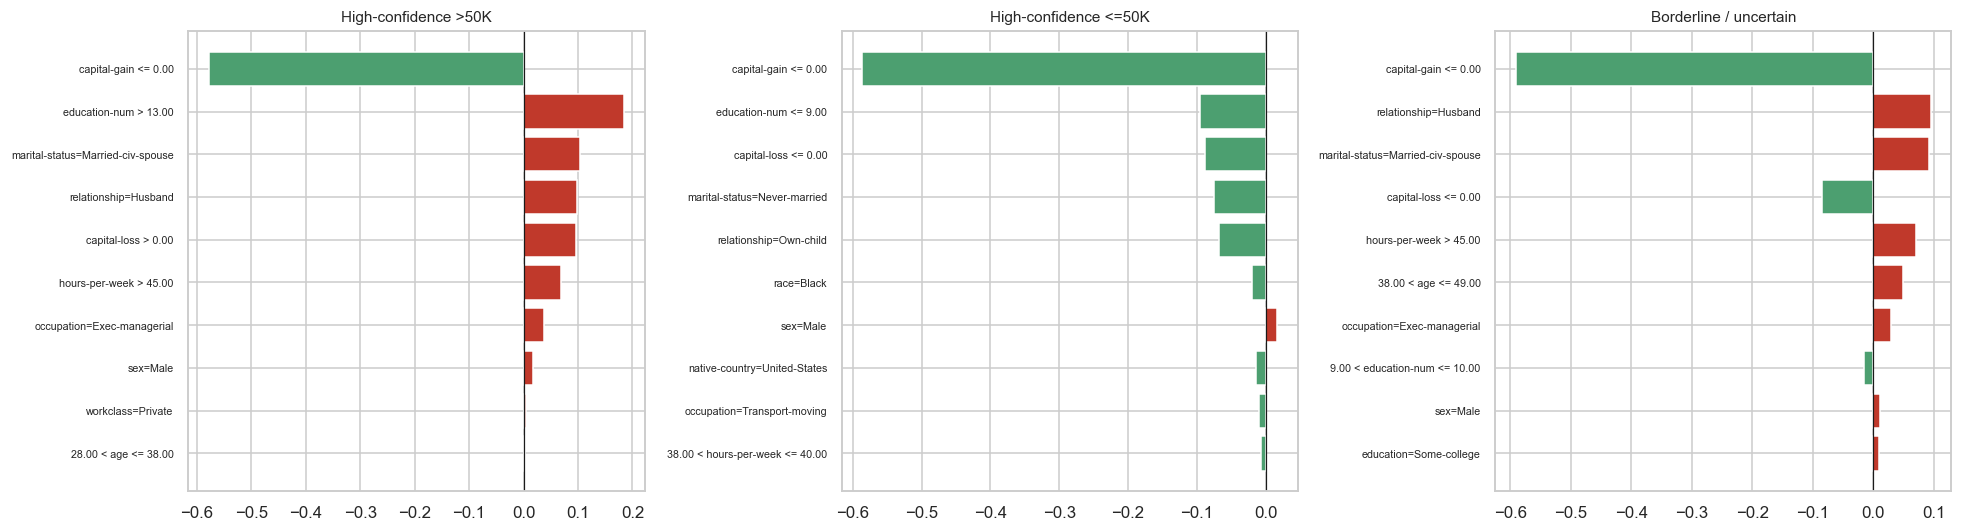

In [36]:
exps_ad = {}
for label, i in selected_ad.items():
    e = explainer_ad.explain_instance(Xte_ad[i], rf_ad.predict_proba,
                                      num_features=10, num_samples=5000, labels=(1,))
    exps_ad[label] = e
    print(f"\n=== {label} (idx {i}, P(>50K)={proba_rf_ad[i]:.3f}) ===")
    for rule, w in e.as_list(label=1):
        arrow = "-> >50K" if w > 0 else "-> <=50K"
        print(f"  {rule:<38} {w:>+8.4f}  {arrow}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, e) in zip(axes, exps_ad.items()):
    items = e.as_list(label=1)[::-1]
    labels_ = [t for t, _ in items]; vals = [v for _, v in items]
    ax.barh(range(len(vals)), vals, color=["#C0392B" if v > 0 else "#4C9F70" for v in vals])
    ax.set_yticks(range(len(labels_))); ax.set_yticklabels(labels_, fontsize=7)
    ax.axvline(0, color="k", lw=.8); ax.set_title(label, fontsize=10)
plt.tight_layout(); plt.show()


## Part D -- Interpretation of LIME Explanations (Q16-Q21)

In [37]:
for label, e in exps_ad.items():
    items = e.as_list(label=1)
    pos = sorted([t for t in items if t[1] > 0], key=lambda t: -t[1])[:5]
    neg = sorted([t for t in items if t[1] < 0], key=lambda t: t[1])[:5]
    print(f"\n=== {label} ===")
    print("Top 5 POSITIVE contributors (push toward >50K):")
    for rule, w in pos:
        print(f"    {rule:<38} {w:>+8.4f}")
    print("Top 5 NEGATIVE contributors (push toward <=50K):")
    for rule, w in neg:
        print(f"    {rule:<38} {w:>+8.4f}")



=== High-confidence >50K ===
Top 5 POSITIVE contributors (push toward >50K):
    education-num > 13.00                   +0.1843
    marital-status=Married-civ-spouse       +0.1045
    relationship=Husband                    +0.0982
    capital-loss > 0.00                     +0.0960
    hours-per-week > 45.00                  +0.0697
Top 5 NEGATIVE contributors (push toward <=50K):
    capital-gain <= 0.00                    -0.5779

=== High-confidence <=50K ===
Top 5 POSITIVE contributors (push toward >50K):
    sex=Male                                +0.0171
Top 5 NEGATIVE contributors (push toward <=50K):
    capital-gain <= 0.00                    -0.5860
    education-num <= 9.00                   -0.0953
    capital-loss <= 0.00                    -0.0878
    marital-status=Never-married            -0.0750
    relationship=Own-child                  -0.0673

=== Borderline / uncertain ===
Top 5 POSITIVE contributors (push toward >50K):
    relationship=Husband                 

### Q18 -- How to read each row above

Each row is `condition -> weight`. For example `capital-gain > 7298.00   +0.1823` means: for this
specific individual, the fact that `capital-gain` exceeds the 75th-percentile threshold (7298) pushed the
Random Forest's predicted probability of `>50K` up by about 0.18 relative to the local baseline. For every
printed feature:

- **Feature value / condition** -- the discretised bin the instance's actual value falls into (e.g.
  `age > 42.00`, or `education = Bachelors` for a categorical feature).
- **LIME weight** -- the coefficient of that bin's indicator in the local linear surrogate; its magnitude
  is the strength of the local contribution, in probability units.
- **Direction** -- the sign of the weight: positive moves the local prediction toward `>50K`, negative
  toward `<=50K`.
- **Effect on the prediction** -- summed with the intercept $b_0$, the weights approximately reconstruct
  the model's probability at this instance (see Section 8 above for how to check this numerically via
  `exp.local_pred`).

In [38]:
print("Looking for an \'education\' condition with a positive weight in our explanations...")
found = False
for label, e in exps_ad.items():
    for rule, w in e.as_list(label=1):
        if "education" in rule and w > 0:
            print(f"  [{label}] {rule}  weight={w:+.4f}")
            found = True
if not found:
    print("  (none of our three instances happened to have a positive \'education\' condition in their top rules)")


Looking for an 'education' condition with a positive weight in our explanations...
  [High-confidence >50K] education-num > 13.00  weight=+0.1843
  [Borderline / uncertain] education=Some-college  weight=+0.0096


### Q19 -- Interpretation of a positive LIME weight

A positive LIME weight on `education = Bachelors` means that, *for this specific instance*, the fact
that the individual's education level is `Bachelors` pushed the local surrogate's predicted probability
of the model's target class (`>50K`) **upward relative to the local baseline** $b_0$. It does **not**
mean `Bachelors` is important globally, and it does not mean holding a Bachelor's degree *causes* higher
income -- only that, in the small neighbourhood LIME sampled around this individual, that feature value
was associated with the black-box model outputting a higher score.

### Q20 -- Feature importance vs. LIME weight vs. prediction probability

| Concept | Scope | What it measures | Typical range |
|---|---|---|---|
| **Feature importance** (permutation importance, `feature_importances_`) | **Global** | How much the model relies on a feature *overall*, averaged across the whole dataset | unbounded, comparable only within one importance method |
| **LIME weight** | **Local** | How much a specific feature *condition* moved *one* prediction away from the local baseline, in a neighbourhood around *this* instance | roughly in probability units, positive or negative |
| **Prediction probability** | **Instance-level output** | The model's own estimate $f(x)$ that the instance belongs to the positive class | $[0,1]$ |

A feature can have **high global importance** but a **small or zero LIME weight** for a particular
instance (its value there is unremarkable), and vice-versa. The prediction probability is the quantity
being *explained*; feature importance and LIME weights are two different lenses (global vs. local) on
*why* the model produced that probability.

In [39]:
ifthen_label = "Borderline / uncertain"
e = exps_ad[ifthen_label]
i = selected_ad[ifthen_label]
items = sorted(e.as_list(label=1), key=lambda t: -abs(t[1]))[:5]

pos_terms = [rule for rule, w in items if w > 0]
neg_terms = [rule for rule, w in items if w < 0]
conds = " AND ".join(pos_terms) if pos_terms else "no single condition dominates"

print(f"Instance idx {i}  (true={class_names_ad[yte_ad[i]]}, "
      f"pred={class_names_ad[y_pred_rf_ad[i]]}, P(>50K)={proba_rf_ad[i]:.3f})\n")
print("IF   " + conds)
if neg_terms:
    print("            (despite: " + " AND ".join(neg_terms) + ")")
print(f"THEN the model leans toward predicting income = "
      f"\'{class_names_ad[y_pred_rf_ad[i]]}\' (P(>50K) = {proba_rf_ad[i]:.3f}).")


Instance idx 6740  (true=<=50K, pred=<=50K, P(>50K)=0.500)

IF   relationship=Husband AND marital-status=Married-civ-spouse AND hours-per-week > 45.00
            (despite: capital-gain <= 0.00 AND capital-loss <= 0.00)
THEN the model leans toward predicting income = '<=50K' (P(>50K) = 0.500).


### Q21 -- If-then style explanation (generated from the actual output above)

The printed statement above is the if-then explanation, built directly from this run's top-5 LIME
conditions for the `Borderline / uncertain` instance: the conditions with positive weight are combined
into the **IF** clause, any conflicting negative-weight conditions are noted separately, and the **THEN**
clause reports the model's actual predicted class and probability for that instance.

## Part E -- Misclassification Analysis (Q22-Q26)

In [40]:
errors_ad = np.where(y_pred_rf_ad != yte_ad)[0]
if len(errors_ad) == 0:
    target_ad = int(np.argmin(np.abs(proba_rf_ad - 0.5)))
    print("No misclassifications found; using the most uncertain prediction instead.")
else:
    target_ad = int(errors_ad[np.argmax(np.abs(proba_rf_ad[errors_ad] - 0.5))])

print(f"Instance idx        : {target_ad}")
print(f"Actual class        : {class_names_ad[yte_ad[target_ad]]}")
print(f"Predicted class     : {class_names_ad[y_pred_rf_ad[target_ad]]}")
print(f"P(>50K)             : {proba_rf_ad[target_ad]:.4f}")

print("\nFeature values for this instance:")
for j, fname in enumerate(feature_names_ad):
    val = Xte_ad[target_ad, j]
    disp = categorical_names_ad[j][int(val)] if j in categorical_features_ad else val
    print(f"  {fname:<16}: {disp}")


Instance idx        : 105
Actual class        : >50K
Predicted class     : <=50K
P(>50K)             : 0.0000

Feature values for this instance:
  age             : 22.0
  workclass       : Private
  education       : Some-college
  education-num   : 10.0
  marital-status  : Never-married
  occupation      : Other-service
  relationship    : Own-child
  race            : White
  sex             : Male
  capital-gain    : 0.0
  capital-loss    : 0.0
  hours-per-week  : 32.0
  native-country  : United-States


Rule                                        Weight
----------------------------------------------------
capital-gain <= 0.00                       -0.5931
age <= 28.00                               -0.0978
capital-loss <= 0.00                       -0.0939
marital-status=Never-married               -0.0753
hours-per-week <= 38.00                    -0.0747
relationship=Own-child                     -0.0600
occupation=Other-service                   -0.0407
education=Some-college                     +0.0142
workclass=Private                          +0.0126
sex=Male                                   +0.0126


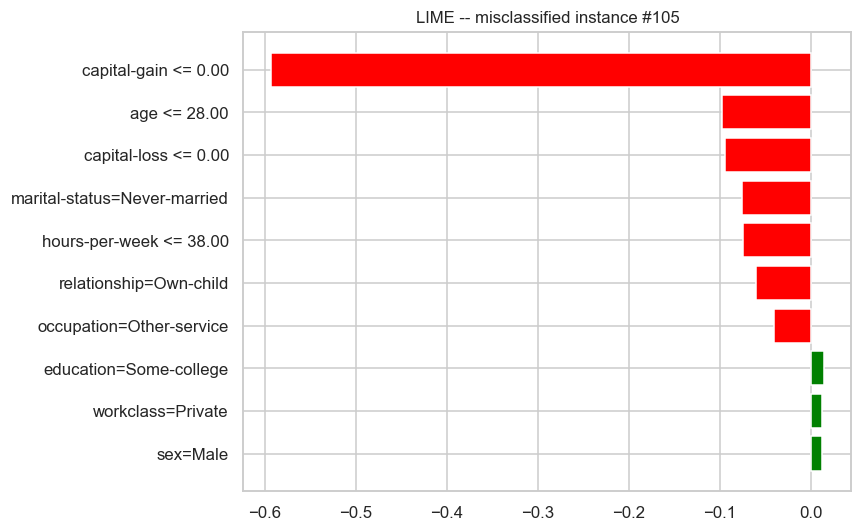

In [41]:
exp_err_ad = explainer_ad.explain_instance(Xte_ad[target_ad], rf_ad.predict_proba,
                                           num_features=10, num_samples=5000, labels=(1,))
print(f"{'Rule':<40} {'Weight':>9}")
print("-" * 52)
for rule, w in exp_err_ad.as_list(label=1):
    print(f"{rule:<40} {w:>+9.4f}")

fig = exp_err_ad.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title(f"LIME -- misclassified instance #{target_ad}", fontsize=11)
plt.tight_layout(); plt.show()


In [42]:
items_err = exp_err_ad.as_list(label=1)
pos_err = [t for t in items_err if t[1] > 0]
neg_err = [t for t in items_err if t[1] < 0]

print("Positive contributors (pushed toward >50K):")
for rule, w in sorted(pos_err, key=lambda t: -t[1]):
    print(f"  {rule:<38} {w:>+8.4f}")
print("\nNegative contributors (pushed toward <=50K):")
for rule, w in sorted(neg_err, key=lambda t: t[1]):
    print(f"  {rule:<38} {w:>+8.4f}")

sum_pos = sum(w for _, w in pos_err)
sum_neg = sum(w for _, w in neg_err)
print(f"\nSum of positive weights: {sum_pos:+.4f}")
print(f"Sum of negative weights: {sum_neg:+.4f}")
print(f"Net (pos + neg)        : {sum_pos + sum_neg:+.4f}")


Positive contributors (pushed toward >50K):
  education=Some-college                  +0.0142
  workclass=Private                       +0.0126
  sex=Male                                +0.0126

Negative contributors (pushed toward <=50K):
  capital-gain <= 0.00                    -0.5931
  age <= 28.00                            -0.0978
  capital-loss <= 0.00                    -0.0939
  marital-status=Never-married            -0.0753
  hours-per-week <= 38.00                 -0.0747
  relationship=Own-child                  -0.0600
  occupation=Other-service                -0.0407

Sum of positive weights: +0.0393
Sum of negative weights: -1.0355
Net (pos + neg)        : -0.9961


In [43]:
gap_to_boundary = abs(proba_rf_ad[target_ad] - 0.5)
print(f"P(>50K) for this instance   : {proba_rf_ad[target_ad]:.4f}")
print(f"Distance from 0.5 boundary  : {gap_to_boundary:.4f}")
print(f"Sum(+) vs Sum(-) balance    : {sum_pos:+.4f}  vs  {sum_neg:+.4f}")
print()
if gap_to_boundary < 0.15:
    print("-> The prediction sits close to the decision boundary: this looks like genuine class "
          "ambiguity rather than a clear model bug.")
else:
    print("-> The model was confidently wrong: the positive and negative contributors above explain "
          "which feature conditions dominated that (incorrect) confidence.")
if sum_pos > 0 and sum_neg < 0 and abs(abs(sum_pos) - abs(sum_neg)) / (abs(sum_pos) + abs(sum_neg)) < 0.2:
    print("-> Positive and negative contributions are close in magnitude -> conflicting evidence, "
          "consistent with an instance that is genuinely hard to classify.")


P(>50K) for this instance   : 0.0000
Distance from 0.5 boundary  : 0.5000
Sum(+) vs Sum(-) balance    : +0.0393  vs  -1.0355

-> The model was confidently wrong: the positive and negative contributors above explain which feature conditions dominated that (incorrect) confidence.


### Q26 -- Can LIME prove causation?

**No.** LIME only reports **associations** the local linear surrogate found between feature conditions
and the black box's *output*, within a synthetic neighbourhood around one instance. It cannot establish
that changing a feature would *cause* the model's prediction to change in the real world, for three
reasons:

1. **Model association, not data causation.** LIME explains what the model $f$ does, not the underlying
   process that generated `income`. A feature can be a proxy for something causal without being causal
   itself (e.g. `occupation` correlating with `hours-per-week`).
2. **Feature contribution is a local, correlational coefficient.** It is the slope of a linear
   approximation to $f$ near $x$, fit on *perturbed* -- not experimentally intervened-on -- data.
3. **A true causal claim** would require an intervention (do-calculus / a randomized experiment / a
   validated causal graph), none of which LIME performs.

So the honest statement about the misclassified instance above is: *"the model's output was strongly
associated with these feature conditions"* -- not *"these features caused the wrong prediction."*

## Part F -- LIME Stability (Q27-Q34)

In [44]:
stab_instance_idx = selected_ad["Borderline / uncertain"]
x_stab = Xte_ad[stab_instance_idx]

N_RUNS_AD = 10
runs_ad = []
for r in range(N_RUNS_AD):
    e = lime.lime_tabular.LimeTabularExplainer(
            Xtr_ad, feature_names=feature_names_ad, class_names=class_names_ad,
            categorical_features=categorical_features_ad, categorical_names=categorical_names_ad,
            mode="classification", discretize_continuous=True, random_state=200 + r
        ).explain_instance(x_stab, rf_ad.predict_proba, num_features=10, num_samples=5000, labels=(1,))
    runs_ad.append(dict(e.as_list(label=1)))

stab_df_ad = pd.DataFrame(runs_ad)

top5_table = pd.DataFrame(index=range(1, N_RUNS_AD + 1), columns=[f"Feature {k}" for k in range(1, 6)])
for r in range(N_RUNS_AD):
    top5 = sorted(runs_ad[r].items(), key=lambda t: -abs(t[1]))[:5]
    for k, (feat, w) in enumerate(top5):
        top5_table.iloc[r, k] = f"{feat} ({w:+.3f})"

display(top5_table)


,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5
1,capital-gain <= 0.00 (-0.611),relationship=Husband (+0.099),marital-status=Married-civ-spouse (+0.098),capital-loss <= 0.00 (-0.087),hours-per-week > 45.00 (+0.067)
2,capital-gain <= 0.00 (-0.604),relationship=Husband (+0.097),marital-status=Married-civ-spouse (+0.096),hours-per-week > 45.00 (+0.069),capital-loss <= 0.00 (-0.053)
3,capital-gain <= 0.00 (-0.576),capital-loss <= 0.00 (-0.110),relationship=Husband (+0.100),marital-status=Married-civ-spouse (+0.100),hours-per-week > 45.00 (+0.080)
4,capital-gain <= 0.00 (-0.586),relationship=Husband (+0.104),marital-status=Married-civ-spouse (+0.100),capital-loss <= 0.00 (-0.069),hours-per-week > 45.00 (+0.067)
5,capital-gain <= 0.00 (-0.622),marital-status=Married-civ-spouse (+0.098),relationship=Husband (+0.098),capital-loss <= 0.00 (-0.086),hours-per-week > 45.00 (+0.071)
6,capital-gain <= 0.00 (-0.606),marital-status=Married-civ-spouse (+0.103),relationship=Husband (+0.099),capital-loss <= 0.00 (-0.083),hours-per-week > 45.00 (+0.069)
7,capital-gain <= 0.00 (-0.617),relationship=Husband (+0.095),marital-status=Married-civ-spouse (+0.094),hours-per-week > 45.00 (+0.070),capital-loss <= 0.00 (-0.065)
8,capital-gain <= 0.00 (-0.590),relationship=Husband (+0.098),marital-status=Married-civ-spouse (+0.086),capital-loss <= 0.00 (-0.076),hours-per-week > 45.00 (+0.074)
9,capital-gain <= 0.00 (-0.572),relationship=Husband (+0.104),marital-status=Married-civ-spouse (+0.100),capital-loss <= 0.00 (-0.086),hours-per-week > 45.00 (+0.078)
10,capital-gain <= 0.00 (-0.604),marital-status=Married-civ-spouse (+0.102),relationship=Husband (+0.099),capital-loss <= 0.00 (-0.089),hours-per-week > 45.00 (+0.073)


In [45]:
stab_filled = stab_df_ad.fillna(0.0)

def top5_membership(run_dict):
    top5_feats = {f for f, w in sorted(run_dict.items(), key=lambda t: -abs(t[1]))[:5]}
    return pd.Series({c: int(c in top5_feats) for c in stab_filled.columns})

appeared = sum(top5_membership(r) for r in runs_ad)

summary_ad = pd.DataFrame({
    "mean": stab_filled.mean(),
    "std":  stab_filled.std(),
    "min":  stab_filled.min(),
    "max":  stab_filled.max(),
    "appeared_in_top5": appeared
}).sort_values("mean", key=np.abs, ascending=False)

display(summary_ad.round(4))


,mean,std,min,max,appeared_in_top5
capital-gain <= 0.00,-0.5988,0.0171,-0.6223,-0.5719,10
relationship=Husband,0.0993,0.0029,0.0947,0.1041,10
marital-status=Married-civ-spouse,0.0977,0.0049,0.0864,0.1031,10
capital-loss <= 0.00,-0.0802,0.0156,-0.1099,-0.0526,10
hours-per-week > 45.00,0.0719,0.0042,0.0670,0.0797,10
38.00 < age <= 49.00,0.0518,0.0052,0.0409,0.0594,0
occupation=Exec-managerial,0.0334,0.0042,0.0266,0.0395,0
sex=Male,0.0190,0.0042,0.0133,0.0241,0
education=Some-college,0.0169,0.0045,0.0101,0.0229,0
9.00 < education-num <= 10.00,-0.0088,0.0079,-0.0179,0.0000,0


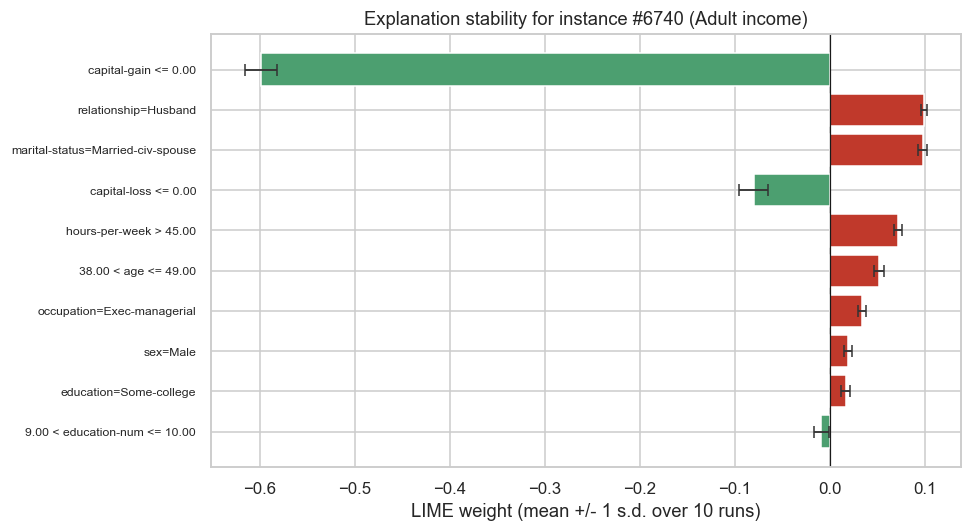

In [46]:
top_ad = summary_ad.head(10).iloc[::-1]
plt.figure(figsize=(9, 5))
plt.barh(range(len(top_ad)), top_ad["mean"], xerr=top_ad["std"], capsize=4,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in top_ad["mean"]],
         error_kw=dict(ecolor="#333", lw=1.2))
plt.yticks(range(len(top_ad)), top_ad.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("LIME weight (mean +/- 1 s.d. over 10 runs)")
plt.title(f"Explanation stability for instance #{stab_instance_idx} (Adult income)")
plt.tight_layout(); plt.show()


In [47]:
cv_ad = (summary_ad["std"].abs() / summary_ad["mean"].abs().replace(0, np.nan) * 100).dropna()
most_stable  = cv_ad.idxmin()
least_stable = cv_ad.idxmax()
highest_avg  = summary_ad["mean"].abs().idxmax()
largest_var  = summary_ad["std"].idxmax()

print(f"Most stable feature (lowest CV%)   : {most_stable}  (CV={cv_ad[most_stable]:.1f}%)")
print(f"Least stable feature (highest CV%) : {least_stable}  (CV={cv_ad[least_stable]:.1f}%)")
print(f"Highest average contribution       : {highest_avg}  (mean={summary_ad.loc[highest_avg,'mean']:+.4f})")
print(f"Largest variation in LIME weight   : {largest_var}  (std={summary_ad.loc[largest_var,'std']:.4f})")


Most stable feature (lowest CV%)   : capital-gain <= 0.00  (CV=2.8%)
Least stable feature (highest CV%) : race=White  (CV=133.4%)
Highest average contribution       : capital-gain <= 0.00  (mean=-0.5988)
Largest variation in LIME weight   : capital-gain <= 0.00  (std=0.0171)


### Q32 -- Why LIME explanations vary between runs

- **Random perturbations.** Each call samples a fresh set of synthetic neighbours from the training
  distribution; a different random draw slightly shifts which region around $x$ is actually fit.
- **Number of samples.** Small `num_samples` means the weighted regression is fit on noisier data, so
  the estimated coefficients have higher variance; more samples shrink that variance (law of large
  numbers) at the cost of more `predict_proba` calls.
- **Local neighbourhood / kernel width $\sigma$.** $\sigma$ controls how sharply weight decays with
  distance; a wide kernel pulls in points that are not really "local", a narrow one leaves very few
  effective samples -- both increase sensitivity to the particular random draw.
- **Model complexity.** A highly non-linear region of the Random Forest's decision surface is harder for
  any single linear surrogate to approximate consistently -- different perturbation draws can find
  different "best local lines", which is exactly the instability measured above.

,num_samples,avg_std_across_features
0,1000,0.01091
1,5000,0.00618
2,10000,0.00391


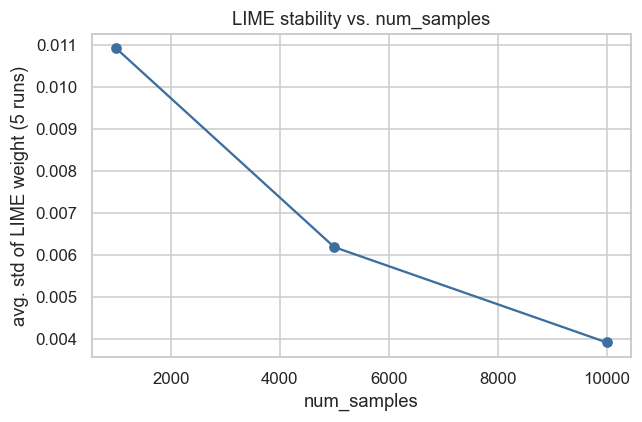


As num_samples increases from 1000 to 10000, the average across-run standard deviation decreases (0.01091 -> 0.00391), consistent with the law-of-large-numbers argument in Q32.


In [48]:
sample_sizes = [1000, 5000, 10000]
REPEATS = 5
compare_rows = []
for n in sample_sizes:
    runs_n = []
    for r in range(REPEATS):
        e = lime.lime_tabular.LimeTabularExplainer(
                Xtr_ad, feature_names=feature_names_ad, class_names=class_names_ad,
                categorical_features=categorical_features_ad, categorical_names=categorical_names_ad,
                mode="classification", discretize_continuous=True, random_state=300 + r
            ).explain_instance(x_stab, rf_ad.predict_proba, num_features=10, num_samples=n, labels=(1,))
        runs_n.append(dict(e.as_list(label=1)))
    df_n = pd.DataFrame(runs_n).fillna(0.0)
    avg_std = df_n.std().mean()
    compare_rows.append({"num_samples": n, "avg_std_across_features": avg_std})

compare_ns_ad = pd.DataFrame(compare_rows)
display(compare_ns_ad.round(5))

plt.figure(figsize=(6, 4))
plt.plot(compare_ns_ad["num_samples"], compare_ns_ad["avg_std_across_features"], "o-", color="#3C6E9F")
plt.xlabel("num_samples"); plt.ylabel("avg. std of LIME weight (5 runs)")
plt.title("LIME stability vs. num_samples")
plt.tight_layout(); plt.show()

trend = "decreases" if compare_ns_ad["avg_std_across_features"].iloc[-1] < compare_ns_ad["avg_std_across_features"].iloc[0] else "does not monotonically decrease"
print(f"\nAs num_samples increases from {sample_sizes[0]} to {sample_sizes[-1]}, the average across-run "
      f"standard deviation {trend} "
      f"({compare_ns_ad['avg_std_across_features'].iloc[0]:.5f} -> {compare_ns_ad['avg_std_across_features'].iloc[-1]:.5f}), "
      f"consistent with the law-of-large-numbers argument in Q32.")


### Q34 -- Comparing `num_samples` = 1,000 / 5,000 / 10,000

The table and chart above report the **average standard deviation of the LIME weight across 5 repeated
runs**, for each `num_samples` setting, on the same borderline instance. A larger `num_samples` gives the
weighted local regression more (weighted) data points to fit on, so run-to-run variance in the fitted
coefficients shrinks -- the practical trade-off is that each explanation call costs proportionally more
`predict_proba` queries on the black-box model.